# 7. What Did It Learn?
### Stage 7 of 7 — looking inside the model's reasoning

---

**How to read this notebook:** This is part of a 7-notebook series that walks through the *entire* research project, step by step, in the same order the actual analysis was done — this one covers stage 7 of 7. Every number and chart here is real, pulled directly from the study's actual data (130 students, 13 puzzles). A few small grey boxes contain code — you don't need to understand the code itself, just run each one (click it, then press Shift+Enter) to see the real result. Nothing needs to be edited.

---

## Overview

Knowing a model predicts reasonably well is only half the story — the more interesting question is **why** it makes the guesses it does. This final stage uses a technique called **SHAP** (don't worry about the acronym) to open up the Decision Tree from Notebook 6 and see, for each individual student, exactly which pieces of evidence pushed its guess toward "High" or toward "Low" — then connects those findings back to what they actually mean about how people search.

## What You'll Learn Here

1. What it means to "explain" an individual prediction, not just a model's overall accuracy
2. How to read a chart that breaks one student's prediction down piece by piece
3. Which measurements the model actually leaned on most, across all 130 students
4. How to connect a statistical measurement back to a real cognitive-science idea
5. Why being honest about a model's blind spots matters as much as reporting its strengths

## Background, Explained Simply

### Why "it's 81% accurate" isn't the whole story

A model that says "High" or "Low" without any explanation isn't very useful to an educator or a researcher. Explaining *why* answers real, practical questions: Which measurements actually matter most? Why did this *specific* student get misjudged? Does the model's reasoning line up with what cognitive science already expects, or does it contradict it?

### The idea behind SHAP, without the maths

Every prediction starts from a neutral "average guess" (based on the whole group), and then every measurement either nudges that guess up (toward "High") or down (toward "Low"). SHAP calculates, fairly, exactly how much credit or blame each individual measurement deserves for the final answer — for one specific student, not just in general. Think of it like a detective's case file: starting from "no evidence yet," each new clue moves the verdict a little, and by the end you can see exactly which clues did the heavy lifting.

### Reading a "waterfall" chart

A waterfall chart shows exactly this, for one real student: it starts at the neutral average guess, then stacks up each measurement's individual push (pink = pushes toward "High," blue = pushes toward "Low"), ending at that student's final predicted score.

## Discussion Questions

1. Two students have the exact same raw measurement (say, the same fixation duration), but SHAP assigns that measurement a different amount of "credit" for each of their predictions. How is that possible — what does it tell you about how SHAP actually works?
2. If one single measurement dominates the model's reasoning for most students, what's the practical risk for the handful of students whose real strategy doesn't fit that typical pattern?
3. Suppose a genuinely strong student gets predicted as "Low." Looking at their personal waterfall chart, how would you use it to investigate *why*, rather than just noting that the model was wrong?
4. If you had to explain this model's biggest limitation to someone in one sentence, without using the word "SHAP," "model," or "accuracy" — what would you say?

---

## Which Measurements Mattered Most, Overall

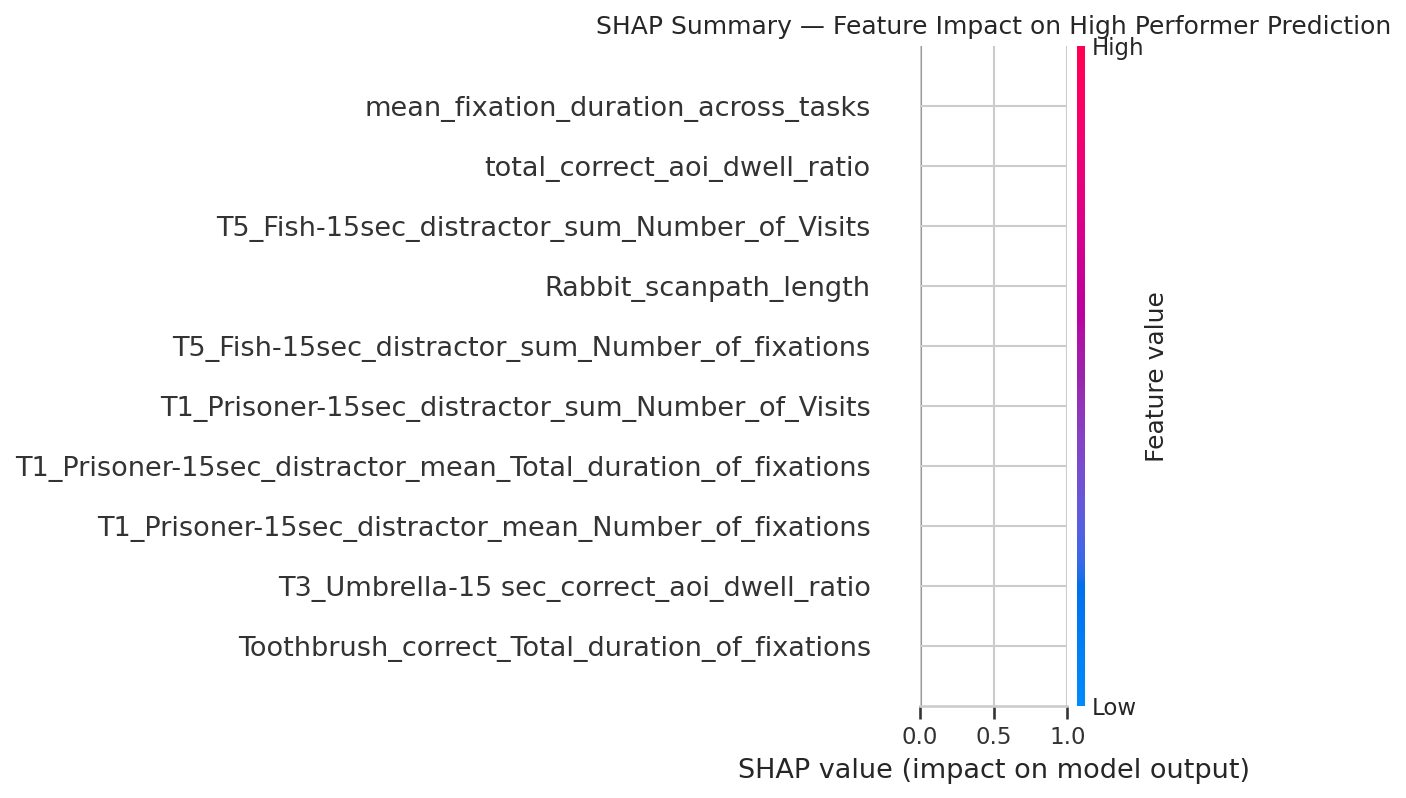

In [4]:
# Run this cell to see which measurements the model leaned on most heavily
from IPython.display import Image
Image(filename='../outputs/figures/07_shap_beeswarm.png')

Each dot on this chart is one real student; its left-right position shows how much that measurement pushed their prediction toward "High" (right) or "Low" (left); its colour shows whether that student's own value for that measurement was high (red) or low (blue).

## A Real Student, Explained Step by Step

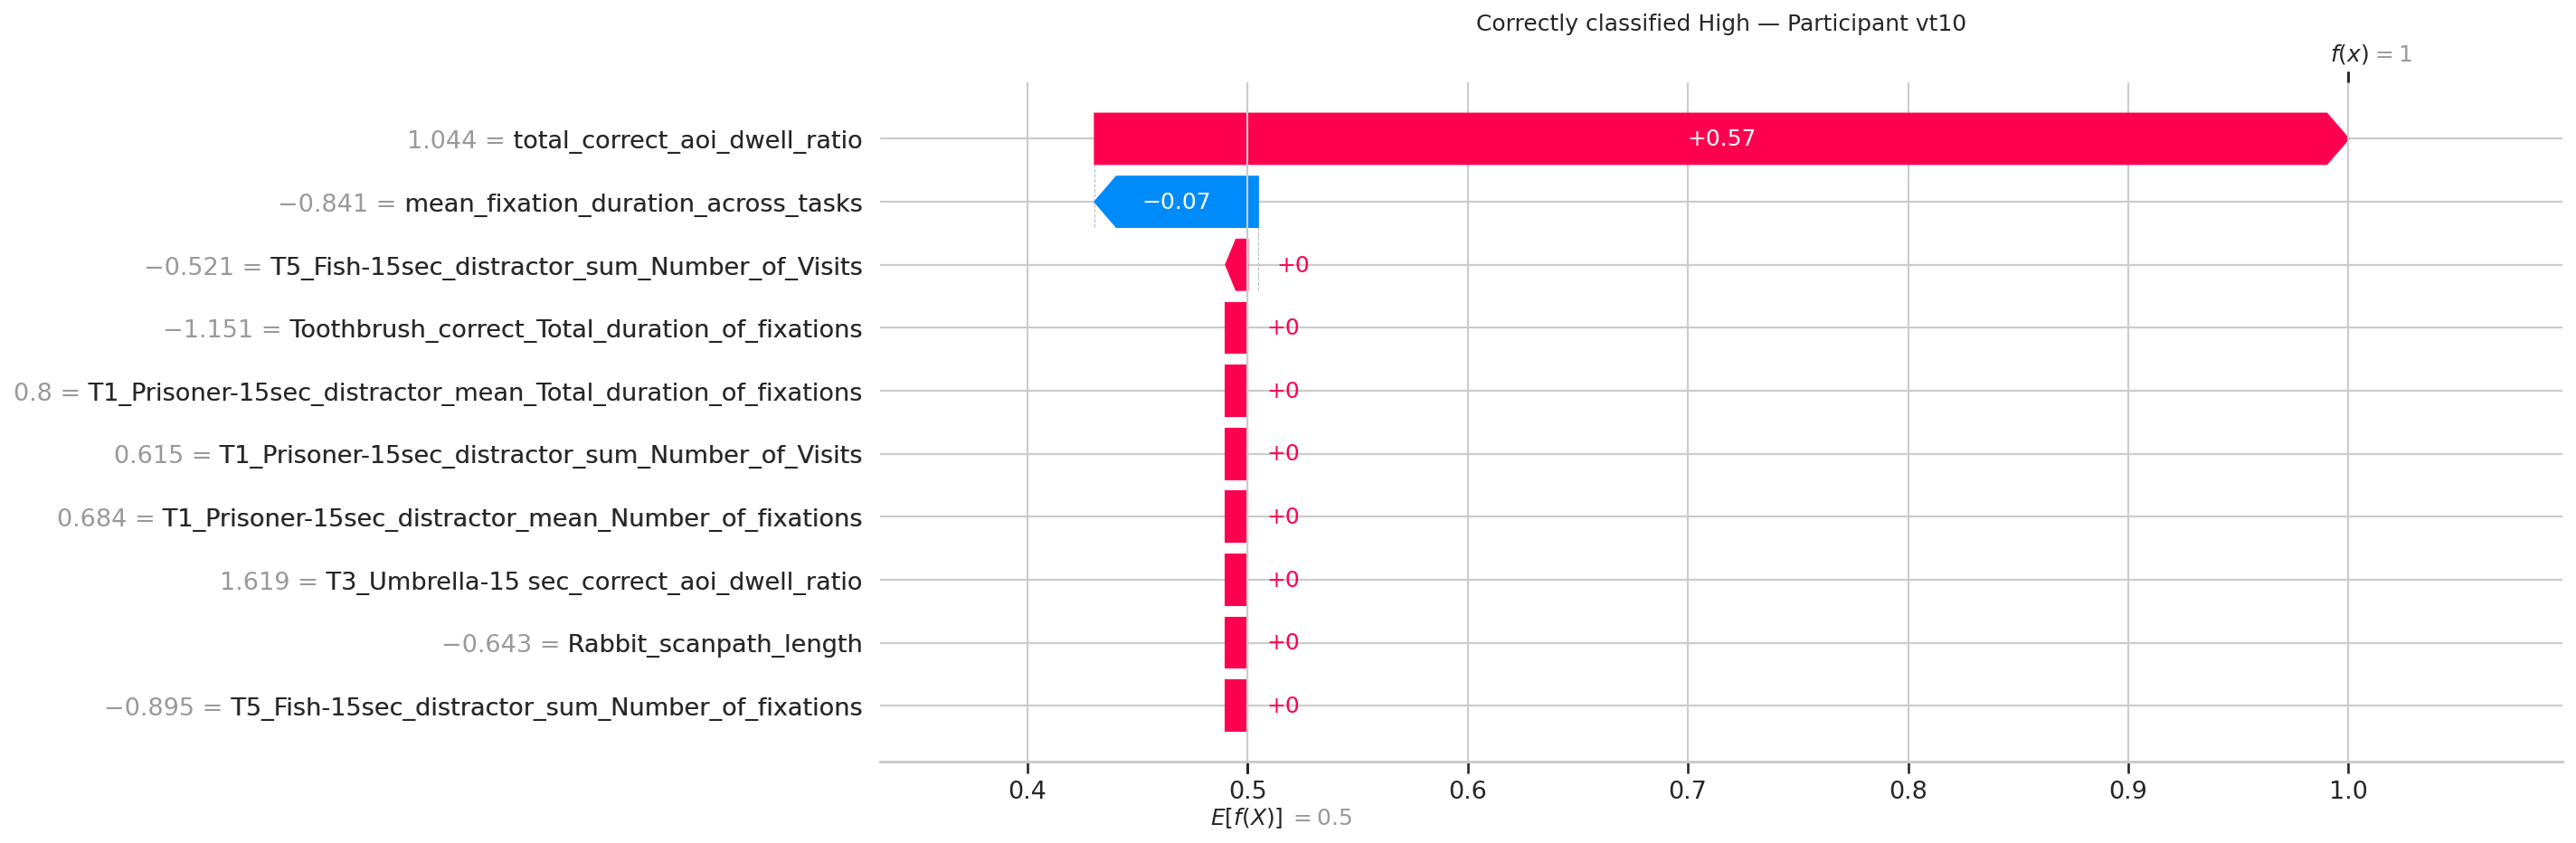

In [5]:
# Run this cell to see one real student's prediction, broken down clue by clue
from IPython.display import Image
Image(filename='../outputs/figures/07_shap_waterfall_Correctly_classified_High.png')

Reading this like a case file: starting from the neutral average guess (top-right label), each row is one measurement pushing the final guess up (pink, toward "High") or down (blue, toward "Low"). For students the model gets *wrong*, the same kind of chart is just as revealing — it shows exactly which clue misled it:

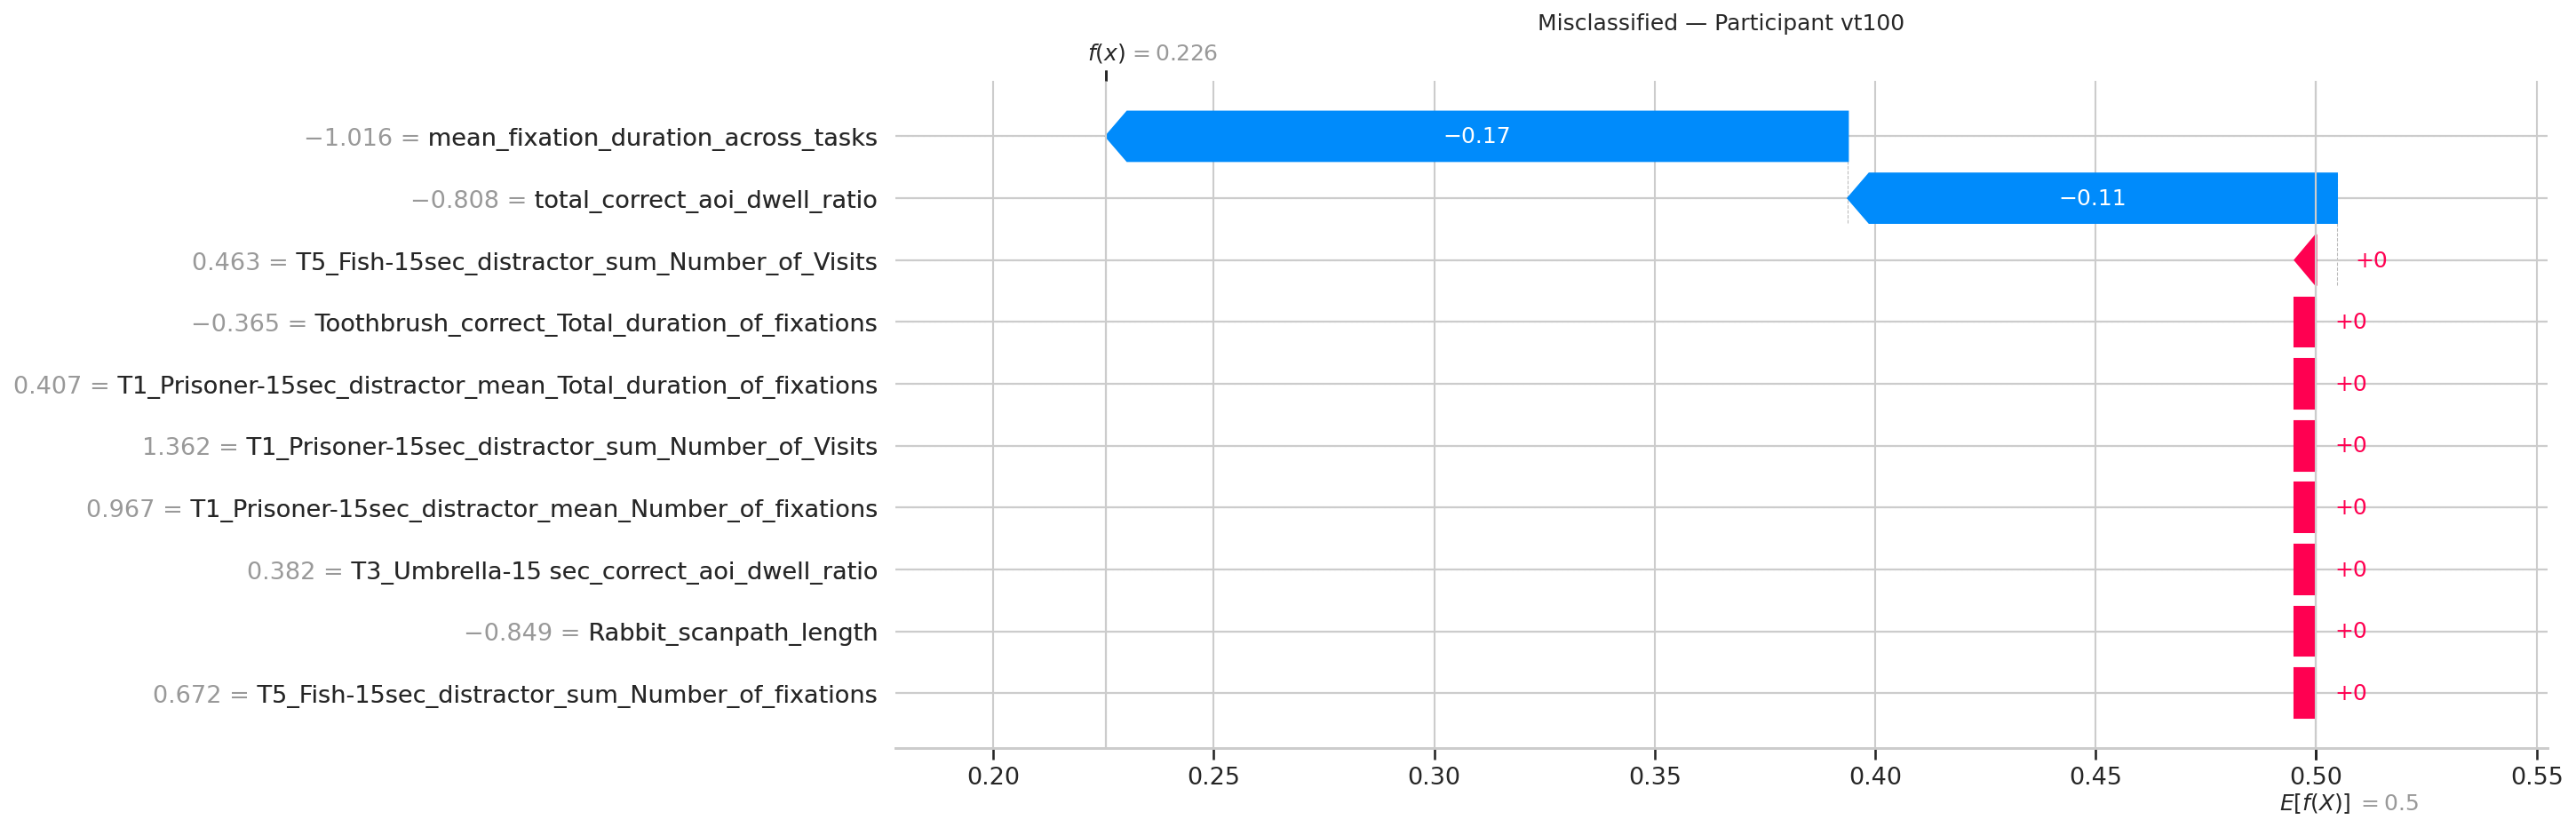

In [6]:
# Run this cell to see a misclassified student's prediction, explained the same way
from IPython.display import Image
Image(filename='../outputs/figures/07_shap_waterfall_Misclassified.png')

## Connecting Measurements to Real Cognitive-Science Ideas

Every measurement the model actually used was mapped back to a plain cognitive-science interpretation — for example:

| Measurement type | What it's thought to reflect |
|---|---|
| Dwell ratio on the correct spot | How focused someone's attention was on the actually-relevant part of the picture |
| Time spent revisiting the wrong spots | Uncertainty, or a checking/verification habit |
| Overall time spent looking, per puzzle | Thoroughness — or, alternatively, just being slower |
| Fixation duration | How deeply each individual glance was being processed |

## What Actually Happened, By the Numbers

- **`mean_fixation_duration_across_tasks`** — how long, on average, each individual glance lasted across all 13 puzzles — turned out to be the **single most influential measurement**, ahead even of dwell ratio. It was the deciding factor for **93 of the 130 students (71.5%)**.
- **`total_correct_aoi_dwell_ratio`** — the dwell-ratio measurement introduced back in Notebook 5 — was the deciding factor for the remaining **37 students (28.5%)**. Between them, these two measurements explain the model's reasoning for every single student in the dataset.
- Refitting the finished model on **all 130 students** (training students plus the 26 held back for the final exam) reached **82.3% overall accuracy** (**84.8% balanced accuracy**) — noticeably higher than the honest 77% hold-out number from Notebook 6, because this number benefits from being trained on the very students it's now being scored on. **The 77% hold-out figure from Notebook 6 remains the fairer, more trustworthy estimate of how this model would perform on a brand-new student.**
- Of the errors that do happen, the same pattern from Notebook 6 shows up again here: the model is noticeably better at correctly spotting **Low**-performing students (52 of 53 caught, 98% recall) than **High**-performing ones (55 of 77 caught, 71% recall).

## Being Honest About the Limits

- **One measurement dominates.** With `mean_fixation_duration_across_tasks` alone deciding the outcome for roughly 7 in 10 students, a student whose successful search strategy doesn't fit that typical pattern is at real risk of being misjudged.
- **It's better at catching struggling students than strong ones.** Anyone using this model's predictions should expect it to under-flag High performers more often than it under-flags Low performers.
- **This is a pattern found in one group of 130 students, on one occasion.** It's a real, statistically solid finding worth investigating further — not a ready-made tool for labelling real students in a classroom.

## Where to Go From Here

This 7-notebook series walked through the *entire* real analysis, one stage at a time, in plain language. From here:

- **[`notebooks_intro/`](../notebooks_intro/01_why_this_research.ipynb)** — a shorter, 4-notebook version of this same story, if you want the highlights without the full stage-by-stage detail
- **[`notebooks/`](../notebooks/01_data_preprocessing.ipynb)** — the complete, code-based technical pipeline this series was built from, for anyone ready to read the actual analysis code

Thank you for reading the whole series — we hope a fairly technical piece of cognitive-science research now feels a lot more approachable, clue by clue.